# Pricing Earthquake Prediction Market Contracts

Analyses the [Polymarket event](https://polymarket.com/event/how-many-6pt5-or-above-earthquakes-april-6-12):
*"How many magnitude 6.5+ earthquakes will occur April 6–12, 2026?"*

Steps:
1. Fetch USGS earthquake data → parquet cache
2. Empirical probability table (M vs T)
3. Fetch Polymarket price histories
4. Empirical estimates for 6.5+ contract
5. Poisson model estimates
6. Comparison plots

## 1  Setup & imports

In [1]:
import json
import math
import os
import time
import urllib.request
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contract parameters
CONTRACT_START = datetime(2026, 4, 6, tzinfo=timezone.utc)
CONTRACT_END   = datetime(2026, 4, 13, tzinfo=timezone.utc)
CONTRACT_DAYS  = (CONTRACT_END - CONTRACT_START).days   # 7
TARGET_MAG     = 6.5
EVENT_SLUG     = "how-many-6pt5-or-above-earthquakes-april-6-12"

# Historical data parameters
HISTORY_YEARS  = 10
MIN_MAG_FETCH  = 4.5
NOW            = datetime(2026, 4, 10, 12, 0, tzinfo=timezone.utc)  # today per CLAUDE.md
END_DATE       = NOW.strftime("%Y-%m-%d")
START_DATE     = NOW.replace(year=NOW.year - HISTORY_YEARS).strftime("%Y-%m-%d")
TOTAL_DAYS     = (NOW - NOW.replace(year=NOW.year - HISTORY_YEARS)).days

MAGNITUDES   = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
TIME_WINDOWS = [1, 2, 3, 4, 5, 6, 7]

USGS_QUERY_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"
GAMMA_API_URL  = "https://gamma-api.polymarket.com/events"
CLOB_URL       = "https://clob.polymarket.com/prices-history"
CACHE_FILE     = "usgs_events.parquet"

print(f"Observation window : {START_DATE}  to  {END_DATE}  ({TOTAL_DAYS} days)")
print(f"Contract window    : {CONTRACT_START.date()}  to  {(CONTRACT_END - timedelta(days=1)).date()}  ({CONTRACT_DAYS} days)")
print(f"Today (simulated)  : {NOW.date()}")

Observation window : 2016-04-10  to  2026-04-10  (3652 days)
Contract window    : 2026-04-06  to  2026-04-12  (7 days)
Today (simulated)  : 2026-04-10


## 2  Fetch USGS earthquake data

Download all events with magnitude >= 4.5 for the past 10 years from the
[USGS Earthquake Catalog](https://earthquake.usgs.gov/fdsnws/event/1/).
Results are cached to a parquet file to avoid re-fetching.

In [2]:
def fetch_all_events(min_mag, start, end):
    """Fetch all earthquakes >= min_mag between start and end. Paginates yearly."""
    start_dt = datetime.fromisoformat(start).replace(tzinfo=timezone.utc)
    end_dt   = datetime.fromisoformat(end).replace(tzinfo=timezone.utc)
    rows = []
    chunk_start = start_dt
    while chunk_start < end_dt:
        chunk_end = min(chunk_start.replace(year=chunk_start.year + 1), end_dt)
        params = (
            f"format=geojson"
            f"&starttime={chunk_start.strftime('%Y-%m-%d')}"
            f"&endtime={chunk_end.strftime('%Y-%m-%d')}"
            f"&minmagnitude={min_mag}"
            f"&orderby=time-asc"
            f"&limit=20000"
        )
        req = urllib.request.Request(
            f"{USGS_QUERY_URL}?{params}", headers={"User-Agent": "Mozilla/5.0"}
        )
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = json.load(resp)
        for feat in data["features"]:
            p = feat["properties"]
            rows.append({
                "time":      datetime.fromtimestamp(p["time"] / 1000, tz=timezone.utc),
                "magnitude": p["mag"],
            })
        print(f"  {chunk_start.year}: {len(data['features'])} events")
        chunk_start = chunk_end
        time.sleep(0.5)
    df = pd.DataFrame(rows)
    df.sort_values("time", inplace=True, ignore_index=True)
    return df


OLD_CACHE = os.path.join("old", "usgs_events.parquet")

if os.path.exists(CACHE_FILE):
    events = pd.read_parquet(CACHE_FILE)
    events["time"] = pd.to_datetime(events["time"], utc=True)
    print(f"Loaded {len(events):,} events from cache: {CACHE_FILE}")
elif os.path.exists(OLD_CACHE):
    events = pd.read_parquet(OLD_CACHE)
    events["time"] = pd.to_datetime(events["time"], utc=True)
    s = datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc)
    e = datetime.fromisoformat(END_DATE).replace(tzinfo=timezone.utc)
    events = events[(events["time"] >= s) & (events["time"] <= e)].copy()
    events.reset_index(drop=True, inplace=True)
    events.to_parquet(CACHE_FILE, index=False)
    print(f"Re-used old cache: {len(events):,} events saved to {CACHE_FILE}")
else:
    print(f"Fetching M{MIN_MAG_FETCH}+ events {START_DATE} to {END_DATE} ...")
    events = fetch_all_events(MIN_MAG_FETCH, START_DATE, END_DATE)
    events.to_parquet(CACHE_FILE, index=False)
    print(f"Total: {len(events):,} events saved to {CACHE_FILE}")

print(f"\nDataset: {len(events):,} events  |  "
      f"mag range {events['magnitude'].min():.1f} to {events['magnitude'].max():.1f}")
events.head()

Loaded 74,601 events from cache: usgs_events.parquet

Dataset: 74,601 events  |  mag range 4.5 to 8.8


,time,magnitude
0,2016-04-10 00:30:19.840000+00:00,4.5
1,2016-04-10 02:14:34.590000+00:00,5.7
2,2016-04-10 04:22:00.930000+00:00,4.9
3,2016-04-10 06:40:51.830000+00:00,4.7
4,2016-04-10 07:11:21.580000+00:00,5.5


## 3  Empirical probability table

For each magnitude threshold M in {4.5, 5.0, ..., 8.0} and time window T in {1...7} days,
divide the historical record into non-overlapping T-day bins and compute the fraction
of bins containing **at least one** earthquake with magnitude >= M.

In [3]:
def empirical_p_atleast1(min_mag, window_days):
    """Fraction of non-overlapping window_days-day bins with >= 1 earthquake of magnitude >= min_mag."""
    start_dt = datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc)
    end_dt   = datetime.fromisoformat(END_DATE).replace(tzinfo=timezone.utc)
    subset   = events[events["magnitude"] >= min_mag]["time"]
    n_bins   = int((end_dt - start_dt).total_seconds() // (window_days * 86400))
    if n_bins == 0:
        return float("nan")
    occupied = set(
        int((t - start_dt).total_seconds() // (window_days * 86400))
        for t in subset if start_dt <= t < end_dt
    )
    return len(occupied) / n_bins


table = {M: {T: empirical_p_atleast1(M, T) for T in TIME_WINDOWS} for M in MAGNITUDES}
prob_table = pd.DataFrame(table, index=TIME_WINDOWS).T
prob_table.index.name   = "Min Magnitude M"
prob_table.columns.name = "Window T (days)"

print("P(>=1 earthquake of magnitude >= M in T days)  --  empirical from USGS\n")
print(prob_table.to_string(float_format="{:.4f}".format))

P(>=1 earthquake of magnitude >= M in T days)  --  empirical from USGS

Window T (days)      1      2      3      4      5      6      7
Min Magnitude M                                                 
4.5             1.0000 1.0000 1.0008 1.0000 1.0014 1.0016 1.0019
5.0             0.9795 0.9995 1.0008 1.0000 1.0014 1.0016 1.0019
5.5             0.6632 0.8888 0.9606 0.9934 0.9986 1.0016 1.0019
6.0             0.2850 0.4830 0.6393 0.7317 0.8151 0.8717 0.8868
6.5             0.0967 0.1818 0.2638 0.3308 0.3890 0.4441 0.4952
7.0             0.0353 0.0690 0.1011 0.1325 0.1630 0.1990 0.2226
7.5             0.0120 0.0241 0.0362 0.0482 0.0603 0.0724 0.0845
8.0             0.0019 0.0038 0.0058 0.0077 0.0096 0.0115 0.0134


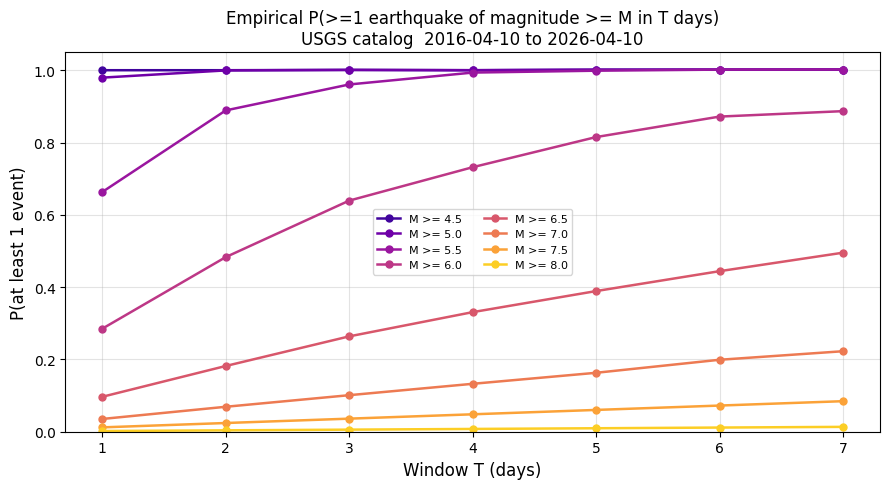

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(MAGNITUDES)))
for M, color in zip(MAGNITUDES, colors):
    ax.plot(TIME_WINDOWS, [table[M][T] for T in TIME_WINDOWS],
            "o-", color=color, linewidth=1.8, markersize=5, label=f"M >= {M}")

ax.set_xlabel("Window T (days)", fontsize=12)
ax.set_ylabel("P(at least 1 event)", fontsize=12)
ax.set_title(
    f"Empirical P(>=1 earthquake of magnitude >= M in T days)\n"
    f"USGS catalog  {START_DATE} to {END_DATE}"
)
ax.set_ylim(0, 1.05)
ax.set_xticks(TIME_WINDOWS)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("empirical_prob_table.png", dpi=150)
plt.show()

## 4  Fit Poisson rate for M >= 6.5

In [5]:
counts  = {M: int((events["magnitude"] >= M).sum()) for M in MAGNITUDES}
rates   = {M: counts[M] / TOTAL_DAYS for M in MAGNITUDES}      # events/day
lambdas = {M: rates[M] * 7 for M in MAGNITUDES}                # events/7-day window

RATE_65 = rates[TARGET_MAG]
LAM_65  = lambdas[TARGET_MAG]

print(f"{'M':>5}  {'events':>8}  {'rate/day':>10}  {'lambda_7day':>13}  {'P(N=0) Poisson':>16}")
print("-" * 58)
for M in MAGNITUDES:
    print(f"{M:>5.1f}  {counts[M]:>8,}  {rates[M]:>10.5f}  "
          f"{lambdas[M]:>13.4f}  {math.exp(-lambdas[M]):>16.4f}")

print(f"\nM>={TARGET_MAG}: r = {RATE_65:.5f} events/day  |  lambda = {LAM_65:.4f} events/week")

    M    events    rate/day    lambda_7day    P(N=0) Poisson
----------------------------------------------------------
  4.5    74,601    20.42744       142.9921            0.0000
  5.0    17,707     4.84858        33.9400            0.0000
  5.5     4,608     1.26177         8.8324            0.0001
  6.0     1,337     0.36610         2.5627            0.0771
  6.5       402     0.11008         0.7705            0.4628
  7.0       135     0.03697         0.2588            0.7720
  7.5        46     0.01260         0.0882            0.9156
  8.0         7     0.00192         0.0134            0.9867

M>=6.5: r = 0.11008 events/day  |  lambda = 0.7705 events/week


## 5  Contract state: observed earthquakes so far

In [6]:
contract_events = events[
    (events["magnitude"] >= TARGET_MAG) &
    (events["time"] >= CONTRACT_START) &
    (events["time"] <  NOW)
].copy()

N_OBSERVED = len(contract_events)
TAU_NOW    = max((CONTRACT_END - NOW).total_seconds() / 86400, 0.0)

print(f"Contract  : {CONTRACT_START.date()} to {(CONTRACT_END - timedelta(days=1)).date()}")
print(f"Today     : {NOW.date()}")
print(f"tau (days remaining) : {TAU_NOW:.2f}")
print(f"n   (observed so far): {N_OBSERVED}")
for _, row in contract_events.iterrows():
    print(f"  * {row['time'].strftime('%Y-%m-%d %H:%M UTC')}  M{row['magnitude']:.1f}")
if contract_events.empty:
    print("  (no M6.5+ events in USGS data for this contract period)")

Contract  : 2026-04-06 to 2026-04-12
Today     : 2026-04-10
tau (days remaining) : 2.50
n   (observed so far): 0
  (no M6.5+ events in USGS data for this contract period)


## 6  Fetch Polymarket price histories for outcomes 0, 1, 2

We use the Gamma API to get event/market metadata, then the CLOB API for price histories.

In [7]:
def normalise_label(label):
    label = label.strip()
    try:
        return str(int(label))
    except ValueError:
        return "3+"


def fetch_gamma_event(slug):
    req = urllib.request.Request(
        f"{GAMMA_API_URL}?slug={slug}", headers={"User-Agent": "Mozilla/5.0"}
    )
    with urllib.request.urlopen(req, timeout=30) as resp:
        return json.load(resp)


def fetch_price_history(token_id, fidelity=60):
    req = urllib.request.Request(
        f"{CLOB_URL}?market={token_id}&interval=all&fidelity={fidelity}",
        headers={"User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(req, timeout=30) as resp:
        data = json.load(resp)
    rows = [
        {"t": datetime.fromtimestamp(pt["t"], tz=timezone.utc), "price": float(pt["p"])}
        for pt in data.get("history", [])
    ]
    df = pd.DataFrame(rows)
    if not df.empty:
        df["tau"] = [(CONTRACT_END - t).total_seconds() / 86400 for t in df["t"]]
    return df


print("Fetching Polymarket event metadata...")
gamma_data = fetch_gamma_event(EVENT_SLUG)
event_info = gamma_data[0]
print(f"Event: {event_info.get('title', 'N/A')}")

bucket_tokens  = {}
current_prices = {}
for market in event_info["markets"]:
    label      = normalise_label(market["groupItemTitle"])
    outcomes   = json.loads(market["outcomes"])
    token_ids  = json.loads(market["clobTokenIds"])
    out_prices = json.loads(market["outcomePrices"])
    yes_idx    = outcomes.index("Yes") if "Yes" in outcomes else 0
    bucket_tokens[label]  = token_ids[yes_idx]
    current_prices[label] = float(out_prices[yes_idx])

print("\nCurrent market prices:")
for k in sorted(current_prices.keys()):
    print(f"  k={k}: {current_prices[k]:.4f}")

print("\nFetching price histories...")
price_histories = {}
for bucket in sorted(bucket_tokens.keys()):
    ph = fetch_price_history(bucket_tokens[bucket])
    price_histories[bucket] = ph
    if not ph.empty:
        print(f"  k={bucket}: {len(ph)} points  tau=[{ph['tau'].max():.2f}, {ph['tau'].min():.2f}]")
    else:
        print(f"  k={bucket}: no data")
    time.sleep(0.3)

Fetching Polymarket event metadata...


Event: How many 6.5 or above earthquakes April 6 - 12?

Current market prices:
  k=0: 0.7250
  k=1: 0.2200
  k=2: 0.0500
  k=3: 0.0085
  k=3+: 0.0015
  k=4: 0.0015
  k=5: 0.0005

Fetching price histories...


  k=0: 107 points  tau=[8.92, 2.23]


  k=1: 44 points  tau=[8.92, 2.23]


  k=2: 44 points  tau=[8.71, 2.23]


  k=3: 39 points  tau=[8.71, 2.23]


  k=3+: 56 points  tau=[8.92, 2.23]


  k=4: 107 points  tau=[8.96, 2.23]


  k=5: 137 points  tau=[9.00, 2.23]


## 7  Empirical estimates for 6.5+ as a function of tau

For each tau (days remaining), compute P(N=k) empirically from historical tau-day windows.
This is the **unconditional prior** (no information about current-week observations).

In [8]:
def empirical_pmf(min_mag, window_days):
    """Return dict k -> fraction of historical window_days-day bins with exactly k events."""
    start_dt = datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc)
    end_dt   = datetime.fromisoformat(END_DATE).replace(tzinfo=timezone.utc)
    subset   = events[events["magnitude"] >= min_mag]["time"]

    win_secs = window_days * 86400
    n_bins   = int((end_dt - start_dt).total_seconds() // win_secs)
    if n_bins == 0:
        return {0: 1.0, 1: 0.0, 2: 0.0, "3+": 0.0}

    bin_counts = np.zeros(n_bins, dtype=int)
    for t in subset:
        if start_dt <= t < end_dt:
            b = int((t - start_dt).total_seconds() // win_secs)
            if b < n_bins:
                bin_counts[b] += 1

    result = {k: int((bin_counts == k).sum()) / n_bins for k in [0, 1, 2]}
    result["3+"] = int((bin_counts >= 3).sum()) / n_bins
    return result


empirical_by_tau = {tau: empirical_pmf(TARGET_MAG, tau) for tau in range(1, CONTRACT_DAYS + 1)}

print(f"Empirical P(N=k) for M>={TARGET_MAG} over tau-day windows (unconditional prior):\n")
print(f"{'tau':>5}  {'P(N=0)':>8}  {'P(N=1)':>8}  {'P(N=2)':>8}  {'P(N=3+)':>9}")
print("-" * 45)
for tau in range(1, CONTRACT_DAYS + 1):
    d = empirical_by_tau[tau]
    print(f"{tau:>5}  {d[0]:>8.4f}  {d[1]:>8.4f}  {d[2]:>8.4f}  {d['3+']:>9.4f}")

Empirical P(N=k) for M>=6.5 over tau-day windows (unconditional prior):

  tau    P(N=0)    P(N=1)    P(N=2)    P(N=3+)
---------------------------------------------
    1    0.9033    0.0871    0.0063     0.0033
    2    0.8182    0.1533    0.0203     0.0082
    3    0.7362    0.2169    0.0337     0.0131
    4    0.6692    0.2530    0.0559     0.0219
    5    0.6110    0.2795    0.0753     0.0342
    6    0.5559    0.3010    0.0954     0.0477
    7    0.5048    0.3167    0.1171     0.0614


## 8  Poisson probability estimates for 6.5+ contract

Given tau days remaining and n earthquakes already observed:

    P(N_total = k | N_so_far = n, tau) = exp(-mu) * mu^(k-n) / (k-n)!

where mu = r * tau and r is the fitted daily rate.

In [9]:
def poisson_fair_price(bucket, tau, n_obs):
    """Fair price of bucket outcome given tau days remaining and n_obs events observed so far."""
    mu = RATE_65 * tau
    if bucket == "3+":
        return 1.0 - sum(poisson_fair_price(str(k), tau, n_obs) for k in range(3))
    k = int(bucket)
    if k < n_obs:
        return 0.0
    j = k - n_obs
    return math.exp(-mu) * mu**j / math.factorial(j)


print(f"Poisson P(N_total=k | n={N_OBSERVED}, tau) for M>={TARGET_MAG}:\n")
print(f"{'tau':>5}  {'P(N=0)':>8}  {'P(N=1)':>8}  {'P(N=2)':>8}  {'P(N=3+)':>9}")
print("-" * 45)
for tau in range(1, CONTRACT_DAYS + 1):
    row = [poisson_fair_price(bkt, float(tau), N_OBSERVED)
           for bkt in ["0", "1", "2", "3+"]]
    print(f"{tau:>5}  {row[0]:>8.4f}  {row[1]:>8.4f}  {row[2]:>8.4f}  {row[3]:>9.4f}")

print(f"\nAt now (tau={TAU_NOW:.2f}, n={N_OBSERVED}):")
for k in ["0", "1", "2", "3+"]:
    pm = poisson_fair_price(k, TAU_NOW, N_OBSERVED)
    mk = current_prices.get(k, float("nan"))
    print(f"  k={k:>3}  Poisson={pm:.4f}  Market={mk:.4f}  diff={pm-mk:+.4f}")

Poisson P(N_total=k | n=0, tau) for M>=6.5:

  tau    P(N=0)    P(N=1)    P(N=2)    P(N=3+)
---------------------------------------------
    1    0.8958    0.0986    0.0054     0.0002
    2    0.8024    0.1767    0.0194     0.0015
    3    0.7188    0.2374    0.0392     0.0047
    4    0.6438    0.2835    0.0624     0.0103
    5    0.5767    0.3174    0.0874     0.0185
    6    0.5166    0.3412    0.1127     0.0295
    7    0.4628    0.3566    0.1374     0.0433

At now (tau=2.50, n=0):
  k=  0  Poisson=0.7594  Market=0.7250  diff=+0.0344
  k=  1  Poisson=0.2090  Market=0.2200  diff=-0.0110
  k=  2  Poisson=0.0288  Market=0.0500  diff=-0.0212
  k= 3+  Poisson=0.0028  Market=0.0015  diff=+0.0013


## 9  Comparison plots

For each outcome k in {0, 1, 2}, plot:
- **Market price** history from Polymarket CLOB
- **Empirical prior** — unconditional historical P(N(tau) = k)
- **Poisson model** — P(N_total = k | n_observed, tau)

x-axis = days remaining (tau), y-axis = probability / price

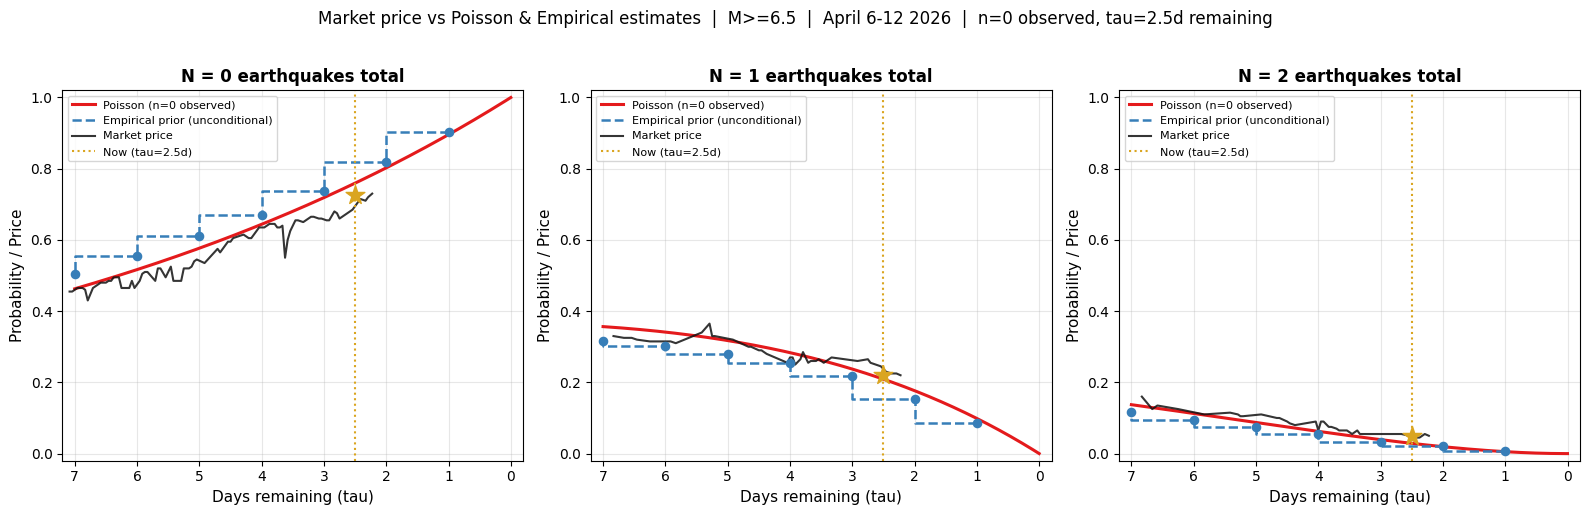

Saved: price_vs_model.png


In [10]:
PLOT_BUCKETS = ["0", "1", "2"]
C_MARKET    = "#111111"
C_POISSON   = "#e41a1c"
C_EMPIRICAL = "#377eb8"

tau_grid = np.linspace(CONTRACT_DAYS, 0.001, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, bucket in zip(axes, PLOT_BUCKETS):

    # Poisson model curve (conditioned on N_OBSERVED)
    poisson_curve = [poisson_fair_price(bucket, tau, N_OBSERVED) for tau in tau_grid]
    ax.plot(tau_grid, poisson_curve,
            color=C_POISSON, linewidth=2.2, linestyle="-",
            label=f"Poisson (n={N_OBSERVED} observed)")

    # Empirical prior (unconditional)
    emp_tau   = np.arange(1, CONTRACT_DAYS + 1, dtype=float)
    k_key     = int(bucket) if bucket != "3+" else "3+"
    emp_probs = [empirical_by_tau[int(t)][k_key] for t in emp_tau]
    ax.step(emp_tau, emp_probs,
            color=C_EMPIRICAL, linewidth=1.8, linestyle="--", where="post",
            label="Empirical prior (unconditional)")
    ax.scatter(emp_tau, emp_probs, color=C_EMPIRICAL, s=35, zorder=4)

    # Market price history
    ph = price_histories.get(bucket, pd.DataFrame())
    if not ph.empty:
        ph_w = ph[(ph["tau"] >= 0) & (ph["tau"] <= CONTRACT_DAYS + 0.1)]
        if not ph_w.empty:
            ax.plot(ph_w["tau"], ph_w["price"],
                    color=C_MARKET, linewidth=1.5, alpha=0.85, label="Market price")

    # Mark current moment
    ax.axvline(TAU_NOW, color="goldenrod", linestyle=":", linewidth=1.5,
               label=f"Now (tau={TAU_NOW:.1f}d)")
    if bucket in current_prices:
        ax.scatter([TAU_NOW], [current_prices[bucket]],
                   marker="*", s=200, color="goldenrod", zorder=6)

    ax.set_title(f"N = {bucket} earthquakes total", fontsize=12, fontweight="bold")
    ax.set_xlabel("Days remaining (tau)", fontsize=11)
    ax.set_ylabel("Probability / Price", fontsize=11)
    ax.set_xlim(CONTRACT_DAYS + 0.2, -0.2)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Market price vs Poisson & Empirical estimates  |  M>={TARGET_MAG}  |  "
    f"April 6-12 2026  |  n={N_OBSERVED} observed, tau={TAU_NOW:.1f}d remaining",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("price_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: price_vs_model.png")

## 10  Mispricing summary

In [11]:
tau_int = max(1, min(CONTRACT_DAYS, round(TAU_NOW)))
print(f"Mispricing snapshot  (tau={TAU_NOW:.2f}d remaining, n={N_OBSERVED} observed)\n")
print(f"{'k':>4}  {'Market':>8}  {'Poisson':>9}  {'Empirical':>11}  {'D Poisson':>11}  {'D Empirical':>13}")
print("-" * 62)
for bucket in ["0", "1", "2", "3+"]:
    p_market  = current_prices.get(bucket, float("nan"))
    p_poisson = poisson_fair_price(bucket, TAU_NOW, N_OBSERVED)
    k_key     = int(bucket) if bucket != "3+" else "3+"
    p_emp     = empirical_by_tau[tau_int].get(k_key, float("nan"))
    print(f"{bucket:>4}  {p_market:>8.4f}  {p_poisson:>9.4f}  {p_emp:>11.4f}  "
          f"{p_poisson-p_market:>+11.4f}  {p_emp-p_market:>+13.4f}")

Mispricing snapshot  (tau=2.50d remaining, n=0 observed)

   k    Market    Poisson    Empirical    D Poisson    D Empirical
--------------------------------------------------------------
   0    0.7250     0.7594       0.8182      +0.0344        +0.0932
   1    0.2200     0.2090       0.1533      -0.0110        -0.0667
   2    0.0500     0.0288       0.0203      -0.0212        -0.0297
  3+    0.0015     0.0028       0.0082      +0.0013        +0.0067
